<a href="https://colab.research.google.com/github/natanalmeida29/analise-de-lucaratividade-no-varejo/blob/main/Projeto_Varejo_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('superstore.csv', encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [2]:
print("Tamanho do Dataset:")
print(df.shape)
print("-" * 30)

print("\nInformações das Colunas:")
df.info()
print("-" * 30)

print("\nValores Nulos por Coluna:")
print(df.isnull().sum())

Tamanho do Dataset:
(10800, 21)
------------------------------

Informações das Colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  object 
 1   Order ID       10800 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Produ

In [3]:
# Precisará Remover todas as 806 linhas fantasmas
df = df.dropna(subset=['Sales'])

# Arrumar os 11 CEPs vazios
df['Postal Code'] = df['Postal Code'].fillna(0)

# Aqui será preciso converter as colunas de Data de texto (object) para formato de data (datetime)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

# Conferindo se a faxina deu certo:
print("Novo tamanho do Dataset:", df.shape)
print("-" * 30)
print("\nNovos tipos de dados nas colunas de Data:")
print(df[['Order Date', 'Ship Date']].dtypes)
print("-" * 30)
print("\nValores Nulos por Coluna agora:")
print(df.isnull().sum())

Novo tamanho do Dataset: (9994, 21)
------------------------------

Novos tipos de dados nas colunas de Data:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object
------------------------------

Valores Nulos por Coluna agora:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [4]:
resumo_categoria = df.groupby('Category')[['Sales', 'Profit']].sum().round(2)
print("=== VENDAS E LUCRO POR CATEGORIA PRINCIPAL ===")
print(resumo_categoria)
print("\n" + "="*45 + "\n")

piores_lucros = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(5).round(2)
print("=== AS 5 SUB-CATEGORIAS QUE MAIS DÃO PREJUÍZO ===")
print(piores_lucros)

=== VENDAS E LUCRO POR CATEGORIA PRINCIPAL ===
                     Sales     Profit
Category                             
Furniture        741999.80   18451.27
Office Supplies  719047.03  122490.80
Technology       836154.03  145454.95


=== AS 5 SUB-CATEGORIAS QUE MAIS DÃO PREJUÍZO ===
Sub-Category
Tables      -17725.48
Bookcases    -3472.56
Supplies     -1189.10
Fasteners      949.52
Machines      3384.76
Name: Profit, dtype: float64


In [5]:
media_desconto_geral = df['Discount'].mean() * 100

desconto_mesas = df[df['Sub-Category'] == 'Tables']['Discount'].mean() * 100

print("=== INVESTIGAÇÃO DE DESCONTOS ===")
print(f"Desconto médio em toda a loja: {media_desconto_geral:.2f}%")
print(f"Desconto médio dado nas Mesas: {desconto_mesas:.2f}%")

=== INVESTIGAÇÃO DE DESCONTOS ===
Desconto médio em toda a loja: 15.62%
Desconto médio dado nas Mesas: 26.13%


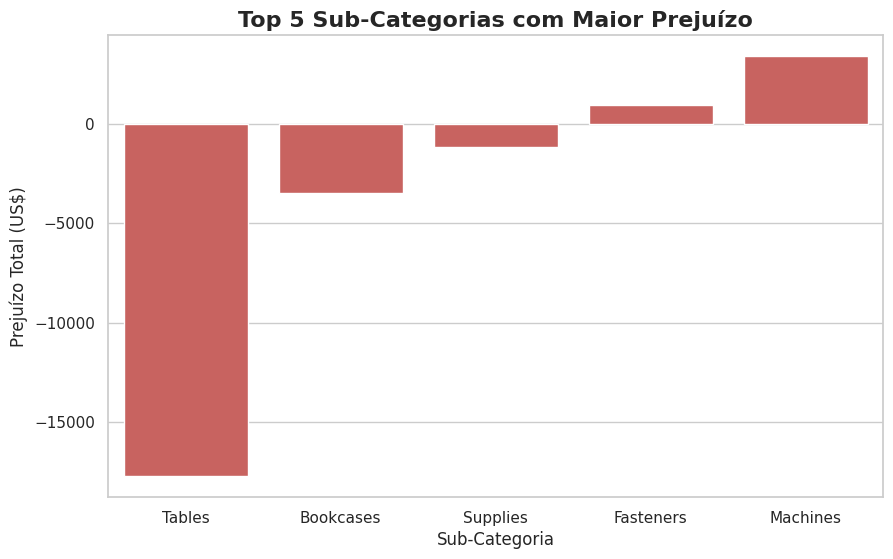


Sucesso! Arquivo 'superstore_limpo.csv' salvo e pronto para o Portfólio!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

piores_lucros = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(5)

sns.barplot(x=piores_lucros.index, y=piores_lucros.values, color='#d9534f')

plt.title('Top 5 Sub-Categorias com Maior Prejuízo', fontsize=16, fontweight='bold')
plt.xlabel('Sub-Categoria', fontsize=12)
plt.ylabel('Prejuízo Total (US$)', fontsize=12)

plt.show()

df.to_csv('superstore_limpo.csv', index=False)
print("\nSucesso! Arquivo 'superstore_limpo.csv' salvo e pronto para o Portfólio!")